# EM mask creation with UNET from Monai
Use Parker (resolution 8nm x 8nm x 16nm in xyz).
Manual Parker mask created at scale 5.
Note: We have not used a vit yet, because we want to verify the performance of a baseline UNET.

### Dependencies
- !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
- !pip install zarr tifffile numpy matplotlib monai scikit-image tqdm scikit-learn einops




In [1]:
## Check if torch mps is available in dev env
import torch
print(torch.backends.mps.is_available())  # Should return True if MPS is available


False


### Set Determinism

In [2]:
import random
import numpy as np
import torch

def set_determinism(seed=42):
    """
    Set determinism for reproducibility.

    Args:
        seed (int): Seed value for random number generators.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def worker_init_fn(worker_id):
    """
    Initialize worker with a fixed seed for reproducibility in DataLoader.

    Args:
        worker_id (int): ID of the worker process.
    """
    seed = torch.initial_seed() % 2**32
    np.random.seed(seed)
    random.seed(seed)

set_determinism(seed=1981)

In [3]:
# set device
device='cuda:0'


# Resume training
resume_training = True

In [5]:
import os
resume_training = False
checkpoint_path = "/media/samia/DATA/PhD/codebases/synapse_extra_projects/Camb/EM_mask_generation/checkpoints"
if resume_training:
    training_dict = torch.load(os.path.join(checkpoint_path,"best_checkpoint.pth"), weights_only=True)


### Visualization

In [34]:
import matplotlib.pyplot as plt
import os
import numpy as np

def visualize(data, mask, prediction=None, epoch=None, save_path=None):
    """
    Visualize the raw data, prediction, and ground truth mask.

    Args:
        data (torch.Tensor): The raw input data.
        mask (torch.Tensor): The ground truth mask.
        prediction (torch.Tensor, optional): The predicted mask.
        epoch (int, optional): Current epoch for logging.
        save_path (str, optional): Directory to save visualizations.
    """
    if data.shape[0] > 1:
        data = data[0, ...]
        mask = mask[0, ...]
    data = data.squeeze().cpu().numpy()
    mask = mask.squeeze().cpu().numpy()
    if prediction is not None:
        prediction = torch.sigmoid(prediction).squeeze().cpu().numpy() > 0.5

    # Find a slice with meaningful mask data (non-zero values)
    slice_idx = None
    for i in range(mask.shape[0]):
        if np.any(mask[i] > 0):  # Check for non-zero values in the mask slice
            slice_idx = i
            print("num non zero", len(np.argwhere(mask[i] > 0)), slice_idx)
            break

    # Default to middle slice if no meaningful slice is found
    if slice_idx is None:
        slice_idx = mask.shape[0] // 2
        print(slice_idx)

    # Plotting
    if prediction is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(data[slice_idx], cmap="gray")
    axes[0].set_title("Raw Data")
   
    axes[1].imshow(mask[slice_idx], cmap="gray")
    axes[1].set_title("Ground Truth")

    if prediction is not None:
        axes[2].imshow(prediction[slice_idx], cmap="gray")
        axes[2].set_title("Prediction")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f"{save_path}/epoch_{epoch}.png" if epoch is not None else f"{save_path}/inference.png")
    plt.show()


In [39]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
import os
import torch

def visualize_3d(data, mask, prediction=None, epoch=None, save_path=None):
    """
    Interactive 3D visualization of EM data, ground truth mask, and predictions.

    Args:
        data (torch.Tensor): The raw input data (B, C, D, H, W) or (C, D, H, W).
        mask (torch.Tensor): The ground truth mask (B, C, D, H, W) or (C, D, H, W).
        prediction (torch.Tensor, optional): The predicted mask (B, C, D, H, W) or (C, D, H, W).
        epoch (int, optional): Current epoch for logging.
        save_path (str, optional): Directory to save visualizations.
    """
    # Remove batch and channel dimensions if present
    if data.dim() == 5:
        data = data[0, 0, ...]
        mask = mask[0, 0, ...]
        if prediction is not None:
            prediction = prediction[0, 0, ...]
    elif data.dim() == 4:
        data = data[0, ...]
        mask = mask[0, ...]
        if prediction is not None:
            prediction = prediction[0, ...]

    # Convert tensors to numpy arrays
    data = data.cpu().numpy() if isinstance(data, torch.Tensor) else data
    mask = mask.cpu().numpy() if isinstance(mask, torch.Tensor) else mask
    if prediction is not None:
        prediction = torch.sigmoid(prediction).cpu().numpy() if isinstance(prediction, torch.Tensor) else prediction
        prediction = prediction > 0.5

    # Initialize plot
    fig, axes = plt.subplots(1, 3 if prediction is not None else 2, figsize=(15, 5))
    plt.subplots_adjust(bottom=0.2)

    # Initialize display with the middle slice
    slice_idx = data.shape[0] // 2

    def update_display(idx):
        idx = int(idx)
        axes[0].imshow(data[idx], cmap="gray")
        axes[0].set_title(f"Raw Data (Slice {idx})")
        axes[0].axis("off")

        axes[1].imshow(mask[idx], cmap="gray")
        axes[1].set_title(f"Ground Truth (Slice {idx})")
        axes[1].axis("off")

        if prediction is not None:
            axes[2].imshow(prediction[idx], cmap="gray")
            axes[2].set_title(f"Prediction (Slice {idx})")
            axes[2].axis("off")

        fig.canvas.draw_idle()

    # Initial plot
    update_display(slice_idx)

    # Add slider for slice selection
    ax_slider = plt.axes([0.25, 0.1, 0.5, 0.03], facecolor="lightgoldenrodyellow")
    slider = Slider(ax_slider, "Slice", 0, data.shape[0] - 1, valinit=slice_idx, valstep=1)

    # Update plot when slider is adjusted
    slider.on_changed(update_display)

    # Save the plot if a save path is provided
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f"{save_path}/epoch_{epoch}.png" if epoch is not None else f"{save_path}/inference.png")

    plt.show()


### Data Loading

In [ ]:
# from torch.utils.data import Subset
# from sklearn.model_selection import train_test_split
# import os
# import zarr
# import numpy as np
# import torch
# from torch.utils.data import Dataset, DataLoader
# from tifffile import imread

# def train_val_test_split(dataset, val_size=0.15, test_size=0.15, seed=42):
#     """
#     Splits the dataset into train, validation, and test subsets.

#     Args:
#         dataset (Dataset): The complete dataset.
#         val_size (float): Fraction of data for validation.
#         test_size (float): Fraction of data for testing.
#         seed (int): Random seed for reproducibility.

#     Returns:
#         tuple: Train, validation, and test datasets.
#     """
#     indices = list(range(len(dataset)))
#     train_idx, temp_idx = train_test_split(indices, test_size=(val_size + test_size), random_state=seed)
#     val_idx, test_idx = train_test_split(temp_idx, test_size=test_size / (val_size + test_size), random_state=seed)

#     train_set = Subset(dataset, train_idx)
#     val_set = Subset(dataset, val_idx)
#     test_set = Subset(dataset, test_idx)

#     return train_set, val_set, test_set




# class EM3DDataset(Dataset):
#     def __init__(self, data_path, mask_path, cube_size=(64, 64, 64), split="train", transform=None):
#         """
#         Args:
#             data_path (str): Path to the 3D EM data (Zarr or TIFF).
#             mask_path (str): Path to the 3D masks (Zarr or TIFF).
#             cube_size (tuple): Dimensions of the 3D cubes to sample (D, H, W).
#             split (str): Dataset split ('train', 'val', 'test').
#             transform (callable, optional): Transformations to apply to data and masks.
#         """
#         self.data_path = data_path
#         self.mask_path = mask_path
#         self.cube_size = cube_size
#         self.split = split
#         self.transform = transform

#         # Load data
#         if data_path.endswith('.zarr'):
#             self.data = zarr.open(data_path, mode='r')[:]
#         elif data_path.endswith('.tiff') or data_path.endswith('.tif'):
#             self.data = imread(data_path)
#         else:
#             raise ValueError("Unsupported file format for data.")

#         if mask_path.endswith('.zarr'):
#             self.masks = zarr.open(mask_path, mode='r')[:]
#         elif mask_path.endswith('.tiff') or mask_path.endswith('.tif'):
#             self.masks = imread(mask_path)
#         else:
#             raise ValueError("Unsupported file format for masks.")

#         assert self.data.shape == self.masks.shape, "Data and masks must have the same shape."

#         self.data_shape = self.data.shape  # (D, H, W)
#         self.cube_depth, self.cube_height, self.cube_width = cube_size

#         # Precompute all possible chunks for validation and test splits
#         if self.split in ["val", "test"]:
#             self.chunks = self._generate_chunks()

#     def _generate_chunks(self):
#         """Generate all possible non-overlapping chunks."""
#         chunks = []
#         for d in range(0, self.data_shape[0] - self.cube_depth + 1, self.cube_depth):
#             for h in range(0, self.data_shape[1] - self.cube_height + 1, self.cube_height):
#                 for w in range(0, self.data_shape[2] - self.cube_width + 1, self.cube_width):
#                     chunks.append((d, h, w))
#         return chunks

#     def __len__(self):
#         if self.split in ["val", "test"]:
#             return len(self.chunks)
#         else:
#             # Arbitrary large number for random sampling in training
#             return 10000
        
#     def __getitem__(self, idx):
#         if self.split in ["val", "test"]:
#             # Sequential sampling
#             d, h, w = self.chunks[idx]
#         else:
#             # Random sampling for training
#             d = np.random.randint(0, self.data_shape[0] - self.cube_depth)
#             h = np.random.randint(0, self.data_shape[1] - self.cube_height)
#             w = np.random.randint(0, self.data_shape[2] - self.cube_width)

#         # Extract the cube
#         sample = self.data[d : d + self.cube_depth, h : h + self.cube_height, w : w + self.cube_width]
#         mask = self.masks[d : d + self.cube_depth, h : h + self.cube_height, w : w + self.cube_width]

#         # Normalize the mask
#         mask = mask / 255.0

#         # Check mask contain data in [0-1]
#         u_mask = np.unique(mask)

#         if u_mask.all() not in [0,1]:
#             raise Exception("Mask contains values other than 0, 1.")

#         if self.transform:
#             sample, mask = self.transform(sample, mask)

        
#         return {
#             'image': torch.tensor(sample, dtype=torch.float32).unsqueeze(0),
#             'mask': torch.tensor(mask, dtype=torch.float32).unsqueeze(0),
#         }


# # Example usage
# data_path = "../Mask_data/s5_Parker.tif"
# mask_path = "../Mask_data/s5_ParkerBrainMask_3.tif"

# cube_size = (64, 64, 64)
# batch_size = 4
# dataset = EM3DDataset(data_path, mask_path, cube_size=cube_size)

# # Split the dataset
# train_set, val_set, test_set = train_val_test_split(dataset)

# # Create dataloaders
# train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, )
# test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

# # Check dataset behavior
# for index, batch in enumerate(train_loader):
#     # if len(np.unique(batch['mask'])) > 1:

#     #     print(f"Train batch: image {batch['image'].shape}, mask {batch['mask'].shape}, uniques in mask:{np.unique(batch['mask'])}")
#     visualize(data=batch['image'], mask=batch['mask'])
#     # break


# for batch in val_loader:
#     print(f"Val batch: image {batch['image'].shape}, mask {batch['mask'].shape}")
#     break

# for batch in test_loader:
#     print(f"Test batch: image {batch['image'].shape}, mask {batch['mask'].shape}")
#     break




train indices 318, val_indices 39, test indices 39
num non zero 3651 0


/tmp/ipykernel_3509423/4271722673.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'image': torch.tensor(data_dict['image'], dtype=torch.float32),
/tmp/ipykernel_3509423/4271722673.py:180: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'mask': torch.tensor(data_dict['mask'], dtype=torch.float32),


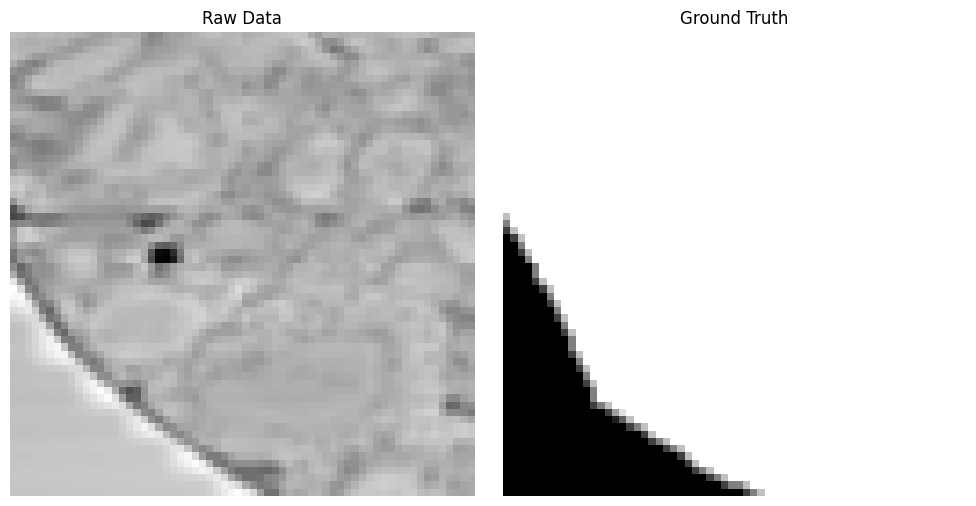

Val batch: image torch.Size([4, 1, 64, 64, 64]), mask torch.Size([4, 1, 64, 64, 64])
num non zero 13 35


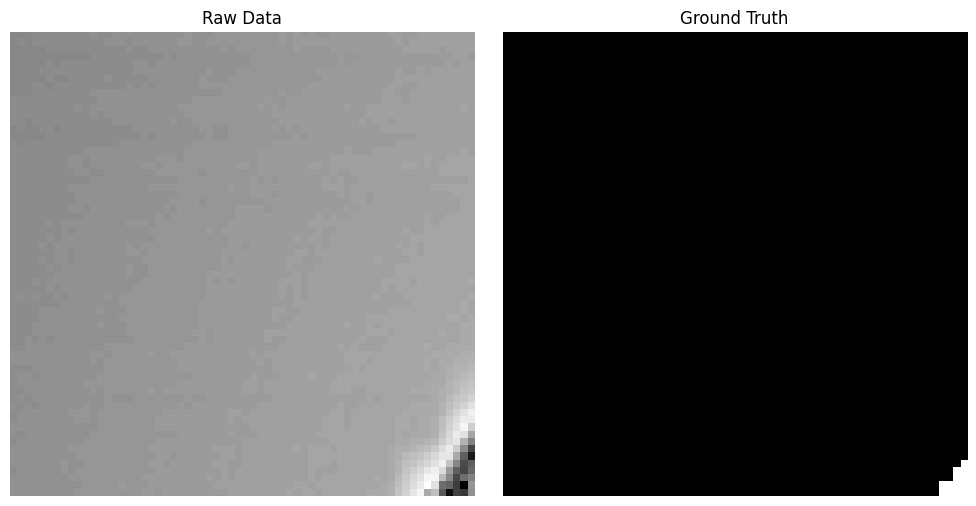

Test batch: image torch.Size([1, 1, 64, 64, 64]), mask torch.Size([1, 1, 64, 64, 64])
32


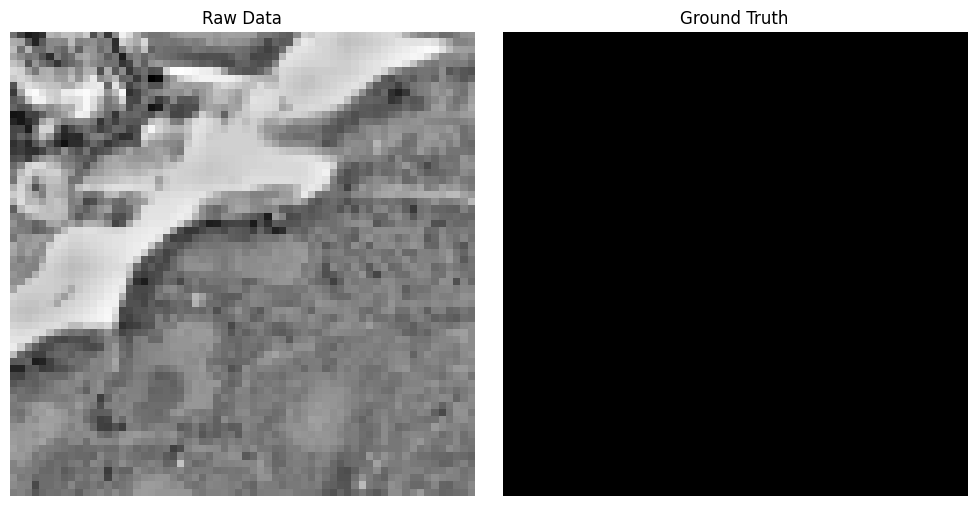

In [92]:
# New Dataset and loading with transforms. Not using randomisation at the getitem level.
import numpy as np
import torch
from torch.utils.data import Dataset
import random
import torchio as tio

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    RandFlipd,
    RandRotate90d,
    RandGaussianNoised,
    RandZoomd,
    RandScaleIntensityd,
    NormalizeIntensityd,
    RandCropByPosNegLabeld
)

def get_train_transform(cube_size):
    return Compose([
        # Intensity normalization
        # ScaleIntensityRanged(keys=["image"], a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
        NormalizeIntensityd(keys=["image"], subtrahend=None, divisor=None),  # Normalize to mean=0.5, std=0.5
        
        # Spatial augmentations
        RandFlipd(keys=["image", "mask"], spatial_axis=[0], prob=0.5),
        RandFlipd(keys=["image", "mask"], spatial_axis=[1], prob=0.5),
        RandFlipd(keys=["image", "mask"], spatial_axis=[2], prob=0.5),
        RandRotate90d(keys=["image", "mask"], prob=0.5, max_k=3),
        RandZoomd(keys=["image", "mask"], min_zoom=0.9, max_zoom=1.1, prob=0.5),

        # Intensity augmentations
        # RandScaleIntensityd(keys=["image"], factors=0.1, prob=0.5),
        # RandGaussianNoised(keys=["image"], prob=0.2),
         # Elastic deformation for non-linear spatial transformation
        # Rand3DElasticd(
        #     keys=["image", "mask"],
        #     sigma_range=(5, 7),  # Standard deviation of deformation
        #     magnitude_range=(1, 2),  # Magnitude of displacement
        #     prob=0.4,
        # ),
        # RandCropByPosNegLabeld(
        #     keys=["image", "label"],
        #     label_key="label",
        #     spatial_size=cube_size,
        #     pos=0.5,
        #     neg=0.5,
        #     num_samples=4,
        #     image_key="image",
        #     image_threshold=0,
        # ),
    ])


def get_val_test_transform():
    return Compose([
        # Intensity normalization
        # ScaleIntensityRanged(keys=["image"], a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
        NormalizeIntensityd(keys=["image"], subtrahend=None, divisor=None),  # Normalize to mean=0.5, std=0.5
    ])


def train_val_test_split(dataset, val_ratio=0.1, test_ratio=0.1, seed=42):
    """
    Splits the dataset into train, val, and test sets based on precomputed indices.

    Args:
        dataset (EM3DDataset): The full dataset.
        val_ratio (float): Fraction of data for validation.
        test_ratio (float): Fraction of data for testing.
        seed (int): Random seed for reproducibility.

    Returns:
        train_indices, val_indices, test_indices
    """
    np.random.seed(seed)

    # Generate all possible chunks (non-overlapping)
    chunks = []
    cube_depth, cube_height, cube_width = dataset.cube_size
    for d in range(0, dataset.data_shape[0] - cube_depth + 1, cube_depth):
        for h in range(0, dataset.data_shape[1] - cube_height + 1, cube_height):
            for w in range(0, dataset.data_shape[2] - cube_width + 1, cube_width):
                chunks.append((d, h, w))

    # Shuffle the chunks
    np.random.shuffle(chunks)

    # Split the indices
    total_chunks = len(chunks)
    test_count = int(total_chunks * test_ratio)
    val_count = int(total_chunks * val_ratio)
    test_indices = chunks[:test_count]
    val_indices = chunks[test_count:test_count + val_count]
    train_indices = chunks[test_count + val_count:]

    return train_indices, val_indices, test_indices



class EM3DDataset(Dataset):
    def __init__(self, data_path, mask_path, cube_size=(64, 64, 64), indices=None, transform=None):
        """
        Args:
            data_path (str): Path to the 3D EM data (Zarr or TIFF).
            mask_path (str): Path to the 3D masks (Zarr or TIFF).
            cube_size (tuple): Dimensions of the 3D cubes to sample (D, H, W).
            indices (list of tuples, optional): List of (d, h, w) indices for chunks.
            transform (callable, optional): Transformations to apply to data and masks.
        """
        self.data_path = data_path
        self.mask_path = mask_path
        self.cube_size = cube_size
        self.transforms = transform

        # Load data
        if data_path.endswith('.zarr'):
            self.data = zarr.open(data_path, mode='r')[:]
        elif data_path.endswith('.tiff') or data_path.endswith('.tif'):
            self.data = imread(data_path)
        else:
            raise ValueError("Unsupported file format for data.")

        if mask_path.endswith('.zarr'):
            self.masks = zarr.open(mask_path, mode='r')[:]
        elif mask_path.endswith('.tiff') or mask_path.endswith('.tif'):
            self.masks = imread(mask_path)
        else:
            raise ValueError("Unsupported file format for masks.")

        assert self.data.shape == self.masks.shape, "Data and masks must have the same shape."

        self.data_shape = self.data.shape
        self.cube_depth, self.cube_height, self.cube_width = cube_size

        # If indices are provided, use them; otherwise, generate random training indices
        if indices is None:
            self.indices = self._generate_random_indices()
        else:
            self.indices = indices

    def _generate_random_indices(self):
        """Generate random indices for training."""
        indices = []
        for _ in range(10000):  # Arbitrary large number for training
            d = np.random.randint(0, self.data_shape[0] - self.cube_depth)
            h = np.random.randint(0, self.data_shape[1] - self.cube_height)
            w = np.random.randint(0, self.data_shape[2] - self.cube_width)
            indices.append((d, h, w))
        return indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        d, h, w = self.indices[idx]

        # Extract the cube
        sample = self.data[d : d + self.cube_depth, h : h + self.cube_height, w : w + self.cube_width]
        mask = self.masks[d : d + self.cube_depth, h : h + self.cube_height, w : w + self.cube_width]
        
        # Normalize the mask
        mask = np.clip(mask / 255.0, 0, 1)
        
        # Prepare data for MONAI transforms
        data_dict = {
            "image": sample[np.newaxis, :, :, :].astype(np.float32),  # Add channel dimension
            "mask": mask[np.newaxis, :, :, :].astype(np.float32),     # Add channel dimension
        }
    
        # Apply MONAI transforms
        if self.transforms:
            data_dict = self.transforms(data_dict)
    
        return {
            'image': torch.tensor(data_dict['image'], dtype=torch.float32),
            'mask': torch.tensor(data_dict['mask'], dtype=torch.float32),
        }



# Example usage
data_path = "../Mask_data/s5_Parker.tif"
mask_path = "../Mask_data/s5_ParkerBrainMask_3.tif"

cube_size = (64, 64, 64)
batch_size = 4
train_transform = get_train_transform(cube_size)
val_test_transform = get_val_test_transform()
# Create the dataset
dataset = EM3DDataset(data_path, mask_path, cube_size=cube_size)

# Split the dataset
train_indices, val_indices, test_indices = train_val_test_split(dataset)

print(f"train indices {len(train_indices)}, val_indices {len(val_indices)}, test indices {len(test_indices)}")
# Create separate datasets for train, val, and test
train_set = EM3DDataset(data_path, mask_path, cube_size=cube_size, indices=None, transform=train_transform)
val_set = EM3DDataset(data_path, mask_path, cube_size=cube_size, indices=val_indices, transform=val_test_transform)
test_set = EM3DDataset(data_path, mask_path, cube_size=cube_size, indices=test_indices, transform=val_test_transform)


# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

for index, batch in enumerate(train_loader):
    # if len(np.unique(batch['mask'])) > 1:

    #     print(f"Train batch: image {batch['image'].shape}, mask {batch['mask'].shape}, uniques in mask:{np.unique(batch['mask'])}")
    visualize(data=batch['image'], mask=batch['mask'])
    break


for batch in val_loader:
    print(f"Val batch: image {batch['image'].shape}, mask {batch['mask'].shape}")
    visualize(data=batch['image'], mask=batch['mask'])
    break

for batch in test_loader:
    print(f"Test batch: image {batch['image'].shape}, mask {batch['mask'].shape}")
    visualize(data=batch['image'], mask=batch['mask'])
    break




### Models

- A ViT backbone that I do not yet how to properly leverage
- Unet
- UnetR??

In [ ]:
import torch
from monai.networks.nets import ViT
from torch.nn import Conv3d, ConvTranspose3d, Sequential, Sigmoid


class ViT3DSegmenter(torch.nn.Module):
    def __init__(self, in_channels=1, out_channels=1, img_size=(64, 64, 64), hidden_size=768):
        """
        Vision Transformer-based 3D segmentation model.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels (1 for binary segmentation).
            img_size (tuple): Input image size (D, H, W).
            hidden_size (int): Hidden size of the transformer.
        """
        super(ViT3DSegmenter, self).__init__()
        
        # Vision Transformer backbone
        self.vit = ViT(
            in_channels=in_channels,
            img_size=img_size,
            patch_size=(16, 16, 16),
            proj_type="conv",
            pos_embed_type="sincos",
            hidden_size=hidden_size,
            dropout_rate=0.1
        )
        
        # Decoder head to reconstruct the segmentation mask
        self.decoder = Sequential(
            Conv3d(hidden_size, hidden_size // 2, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            Conv3d(hidden_size // 2, out_channels, kernel_size=1),
            Sigmoid()  # Apply sigmoid for binary segmentation
        )
    
    def forward(self, x):
        # Pass input through the ViT backbone
        x = self.vit(x)
        
        # Reshape transformer output back to spatial dimensions
        # Assumes ViT outputs [B, C, D/16, H/16, W/16]
        x = x.permute(0, 2, 3, 4, 1).contiguous()  # [B, C, D/16, H/16, W/16] -> [B, D/16, H/16, W/16, C]
        x = x.view(x.shape[0], x.shape[-1], x.shape[1], x.shape[2], x.shape[3])  # Reshape to [B, hidden_size, D/16, H/16, W/16]
        
        # Pass through the decoder to get segmentation mask
        x = self.decoder(x)
        print(x.shape)
        return x

# Instantiate the model
model = ViT3DSegmenter(img_size=(64, 64, 64)).to(device)
print(model)


In [3]:
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

model

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

### Training and Inference

In [6]:
import torch
import torch.optim as optim
import torch.nn as nn
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from tifffile import imread



# Metrics calculation function
def calculate_metrics(prediction, mask):
    """
    Calculate Dice coefficient and Jaccard index.
    
    Args:
        prediction (torch.Tensor): Predicted mask.
        mask (torch.Tensor): Ground truth mask.
    
    Returns:
        dict: A dictionary with Dice and Jaccard scores.
    """
    prediction = torch.sigmoid(prediction).cpu().numpy() > 0.5
    mask = mask.cpu().numpy()
    intersection = np.sum(prediction * mask)
    dice = (2.0 * intersection) / (np.sum(prediction) + np.sum(mask) + 1e-8)
    jaccard = intersection / (np.sum(prediction) + np.sum(mask) - intersection + 1e-8)
    return {"Dice": dice, "Jaccard": jaccard}



In [16]:
# Loss curve plots
def create_learning_curves(train_loss_list, val_loss_list, metric=None, outpath=None, show=False,):
    fig, axs = plt.subplots(2, 1, figsize=(7.5, 10), sharex=False)
    font = 12

    # Plot epoch_loss_list and val_loss_list
    # plot(range(len(epoch_loss_list)), epoch_loss_list, color="C0", linewidth=2.0, label="Train Loss")
    axs[0].plot(range(len(train_loss_list)), train_loss_list, color="C0", linewidth=2.0, label="Train Loss")
    axs[0].plot(range(len(val_loss_list)), val_loss_list, color="C1", linewidth=2.0, label="Validation Loss") # only works when validated every epoch
    axs[0].set_title("Total Loss", fontsize=font)
    axs[0].set_xlabel("Epochs", fontsize=font)
    axs[0].set_ylabel("Loss", fontsize=font)
    axs[0].legend()

    # Plot any metric that is being calculated
    if metric:

        axs[1].plot(range(len(metric)), metric, color="C0", linewidth=2.0,
                    label="Metric")
 
    axs[1].set_title("Metric", fontsize=font)
    axs[1].set_xlabel("Epochs", fontsize=font)
    axs[1].set_ylabel("Metric value (higher better)", fontsize=font)
    axs[1].legend()


    fig.suptitle("Training and Validation Losses", fontsize=font, y=0.95)
    fig.tight_layout(pad=2.0)

    if outpath:

        plt.savefig(os.path.join(outpath, "loss_curves.png"), bbox_inches='tight', dpi=300)
        plt.savefig(os.path.join(outpath, "loss_curves.svg"), bbox_inches='tight', dpi=300)

    if show:
        plt.show()

    plt.close()


In [17]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, path="best_checkpoint.pth"):
        """
        Early stopping to stop training when validation loss doesn't improve.

        Args:
            patience (int): Number of epochs to wait before stopping.
            delta (float): Minimum change to qualify as an improvement.
            path (str): Path to save the best model checkpoint.
        """
        self.patience = patience
        self.delta = delta
        self.path = path
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)
        print(f"Validation loss decreased. Model saved to {self.path}.")


In [87]:
import json
import gc

def train_with_validation(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device=device,# set above
    epochs=50,
    early_stopping_patience=5,
    save_path="./checkpoints",
    results_path="./plots_results"
):
    """
    Training loop with validation, early stopping, and checkpointing.

    Args:
        model (torch.nn.Module): The model to train.
        train_loader (DataLoader): Training data loader.
        val_loader (DataLoader): Validation data loader.
        criterion: Loss function.
        optimizer: Optimizer.
        device (str): Device to train on.
        epochs (int): Maximum number of epochs.
        early_stopping_patience (int): Early stopping patience.
        save_path (str): Directory to save checkpoints.

    Returns:
        dict: Training history with losses and metrics.
    """
    os.makedirs(save_path, exist_ok=True)
    os.makedirs(results_path, exist_ok=True)
    early_stopping = EarlyStopping(patience=early_stopping_patience, path=os.path.join(save_path, "best_checkpoint.pth"))
    history = {"train_loss": [], "val_loss": [], "val_dice": []}
    train_loss_list = []
    val_loss_list = []
    for epoch in range(epochs):
        torch.cuda.empty_cache()
        gc.collect()
        # Training phase
        model.train()
        train_loss = 0
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=110)
        progress_bar.set_description(f"Epoch {epoch}")
        for step, batch in progress_bar:
            data, mask = batch['image'].to(device), batch['mask'].to(device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(data)
            loss = criterion(outputs, mask)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            progress_bar.set_postfix(
            {"loss": train_loss / (step + 1), })

        train_loss /= (step + 1)
        train_loss_list.append(train_loss)
        # Validation phase
        model.eval()
        val_loss = 0
        dice_scores = []
        with torch.no_grad():
            for val_step, batch in tqdm(enumerate(val_loader, start=1), desc=f"Epoch {epoch+1}/{epochs} [Validation]"):
                data, mask = batch['image'].to(device), batch['mask'].to(device)

                data, mask = data.to(device), mask.to(device)
                outputs = model(data)
                val_loss += criterion(outputs, mask).item()


                # Calculate metrics
                metrics = calculate_metrics(outputs, mask)
                dice_scores.append(metrics["Dice"])
                if val_step == 1:
                    if outputs.shape[0]> 1:
                        chosen_pred = outputs[0, ...]
                    # visualize(data=data, mask=mask, prediction=chosen_pred, epoch=epoch)

                progress_bar.set_postfix({"val_loss": val_loss / step, })


        # Calculate average losses and metrics
        val_loss /= val_step
        val_loss_list.append(val_loss)

        avg_dice = np.mean(dice_scores)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(avg_dice)

        # plot losses
        create_learning_curves(train_loss_list=history['train_loss'], val_loss_list=history['val_loss'], metric=history['val_dice'], outpath=results_path)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Dice: {avg_dice:.4f}")


        # Early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    # Save the last checkpoint
    torch.save(model.state_dict(), os.path.join(save_path, "last_checkpoint.pth"))
    print(f"Last model checkpoint saved to {save_path}/last_checkpoint.pth.")

    # Save training history
    with open(os.path.join(save_path, "history.json"), "w") as f:
        json.dump(history, f)
    print(f"Training history saved to {save_path}/history.json.")

    return history


In [95]:
from monai.losses import DiceCELoss
import torch.optim as optim

# Define the criterion for binary segmentation
criterion = DiceCELoss(to_onehot_y=False, sigmoid=True)
# criterion = torch.nn.BCEWithLogitsLoss()

# Training loop
history = train_with_validation(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optim.Adam(model.parameters(), lr=1e-4),
    device=device,
    epochs=1000,
    early_stopping_patience=50,
    save_path="./checkpoints/run6",
    results_path="./plots_results/run6"
)




Epoch 0:   0%|                                                                       | 0/2500 [00:00<?, ?it/s]/tmp/ipykernel_3509423/4271722673.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'image': torch.tensor(data_dict['image'], dtype=torch.float32),
/tmp/ipykernel_3509423/4271722673.py:180: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'mask': torch.tensor(data_dict['mask'], dtype=torch.float32),
Epoch 0: 100%|████████████████████████████████████████████████| 2500/2500 [02:53<00:00, 14.39it/s, loss=0.955]
Epoch 1/1000 [Validation]: 10it [00:00, 39.51it/s]


Epoch 1/1000 - Train Loss: 0.9552, Val Loss: 1.1810, Val Dice: 0.5979
Validation loss decreased. Model saved to ./checkpoints/run6/best_checkpoint.pth.


Epoch 1: 100%|████████████████████████████████████████████████| 2500/2500 [02:53<00:00, 14.41it/s, loss=0.754]
Epoch 2/1000 [Validation]: 10it [00:00, 40.39it/s]


Epoch 2/1000 - Train Loss: 0.7540, Val Loss: 1.1231, Val Dice: 0.7034
Validation loss decreased. Model saved to ./checkpoints/run6/best_checkpoint.pth.


Epoch 2: 100%|████████████████████████████████████████████████| 2500/2500 [02:57<00:00, 14.08it/s, loss=0.671]
Epoch 3/1000 [Validation]: 10it [00:00, 40.70it/s]


...

Epoch 341/1000 - Train Loss: 0.2262, Val Loss: 0.3980, Val Dice: 0.9736


Epoch 341:  58%|██████████████████████████▍                   | 1438/2500 [01:37<01:14, 14.16it/s, loss=0.224]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch 344: 100%|██████████████████████████████████████████████| 2500/2500 [02:53<00:00, 14.40it/s, loss=0.227]
Epoch 345/1000 [Validation]: 10it [00:00, 37.97it/s]


Epoch 345/1000 - Train Loss: 0.2271, Val Loss: 0.3980, Val Dice: 0.9738


Epoch 345:   3%|█▍                                               | 74/2500 [00:05<03:06, 12.98it/s, loss=0.25]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch 347: 100%|██████████████████████████████████████████████| 2500/2500 [02:51<00:00, 14.62it/s, loss=0.226]
Epoch 348/1000 [Validation]: 10it [00:00, 41.96it/s]


Epoch 348/1000 - Train Loss: 0.2262, Val Loss: 0.4030, Val Dice: 0.9636
Early stopping triggered.
Last model checkpoint saved to ./checkpoints/run6/last_checkpoint.pth.
Training history saved to ./checkpoints/run6/history.json.


In [4]:
# load model before testing on best ckpt
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

ckpt = "./checkpoints/run6/best_checkpoint.pth"
model_state_dict = torch.load(ckpt, weights_only=True, map_location=device)
model.load_state_dict(model_state_dict)
model.eval()

/home/samia/anaconda3/envs/syn/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [91]:
def test_model(model, test_loader, device="mps"):
    """
    Test the model on the test dataset.

    Args:
        model (torch.nn.Module): The trained model.
        test_loader (DataLoader): Test data loader.
        device (str): Device to run inference on.

    Returns:
        dict: Test metrics.
    """
    model.eval()
    dice_scores = []
    jaccard_scores = []

    with torch.no_grad():
        for batch in test_loader:
            data, mask = batch['image'].to(device), batch['mask'].to(device)
            outputs = model(data)
            metrics = calculate_metrics(outputs, mask)
            dice_scores.append(metrics["Dice"])
            jaccard_scores.append(metrics["Jaccard"])

    avg_dice = np.mean(dice_scores)
    avg_jaccard = np.mean(jaccard_scores)
    print(f"Test Metrics - Dice: {avg_dice:.4f}, Jaccard: {avg_jaccard:.4f}")
    return {"Dice": avg_dice, "Jaccard": avg_jaccard}


test_model(model, test_loader, device)

/tmp/ipykernel_3509423/391107078.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'image': torch.tensor(data_dict['image'], dtype=torch.float32),


Test Metrics - Dice: 0.6349, Jaccard: 0.6019


{'Dice': 0.634855473209305, 'Jaccard': 0.6019022529993077}

In [73]:
import os
import numpy as np
import torch
from tifffile import imwrite

def test_model(model, test_loader, save_dir, device="mps"):
    """
    Test the model on the test dataset and save predictions.

    Args:
        model (torch.nn.Module): The trained model.
        test_loader (DataLoader): Test data loader.
        save_dir (str): Directory to save predictions.
        device (str): Device to run inference on.

    Returns:
        dict: Test metrics (average Dice and Jaccard scores).
    """
    model.eval()
    dice_scores = []
    jaccard_scores = []

    os.makedirs(save_dir, exist_ok=True)  # Ensure save directory exists

    with torch.no_grad():
        for idx, batch in enumerate(test_loader):
            data, mask = batch['image'].to(device), batch['mask'].to(device)
            outputs = model(data)

            # Apply sigmoid and threshold to get binary predictions
            predictions = torch.sigmoid(outputs) > 0.5

            # Save predictions as files
            for i in range(predictions.shape[0]):  # Iterate over batch
                prediction_np = predictions[i, 0].cpu().numpy().astype(np.uint8) * 255
                mask_np = mask[i, 0].cpu().numpy().astype(np.uint8) * 255

                # Save prediction and corresponding mask
                imwrite(os.path.join(save_dir, f"prediction_{idx}_{i}.tiff"), prediction_np)
                imwrite(os.path.join(save_dir, f"ground_truth_{idx}_{i}.tiff"), mask_np)

            # Calculate metrics for the batch
            metrics = calculate_metrics(outputs, mask)
            dice_scores.append(metrics["Dice"])
            jaccard_scores.append(metrics["Jaccard"])

    avg_dice = np.mean(dice_scores)
    avg_jaccard = np.mean(jaccard_scores)
    print(f"Test Metrics - Dice: {avg_dice:.4f}, Jaccard: {avg_jaccard:.4f}")

    return {"Dice": avg_dice, "Jaccard": avg_jaccard}

test_model(model, test_loader, save_dir="./outputs/run3", device=device)

/tmp/ipykernel_3509423/2253353442.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'image': torch.tensor(data_dict['image'], dtype=torch.float32),


Test Metrics - Dice: 0.6423, Jaccard: 0.6105


{'Dice': 0.6423143242937653, 'Jaccard': 0.6105361542188655}

In [79]:
import torch
import numpy as np
import zarr
from tifffile import imwrite
from tqdm import tqdm

def run_inference_whole_volume(model, data_path, output_path, patch_size=(64, 64, 64), overlap=16, device="mps"):
    """
    Apply the trained model to the entire 3D EM dataset and save the output mask.

    Args:
        model (torch.nn.Module): The trained model.
        data_path (str): Path to the input 3D EM dataset (Zarr or TIFF).
        output_path (str): Path to save the output mask (Zarr or TIFF).
        patch_size (tuple): Size of the 3D patches to process at a time.
        overlap (int): Overlap between patches to ensure smooth predictions.
        device (str): Device to run inference on.
    """
    # Load input dataset
    if data_path.endswith('.zarr'):
        em_data = zarr.open(data_path, mode='r')[:]
    elif data_path.endswith('.tiff') or data_path.endswith('.tif'):
        from tifffile import imread
        em_data = imread(data_path)
    else:
        raise ValueError("Unsupported file format for input data.")

    model.eval()
    model.to(device)

    # Prepare output array
    output_mask = np.zeros_like(em_data, dtype=np.uint8)
    weight_map = np.zeros_like(em_data, dtype=np.float32)  # For blending overlapping predictions

    # Sliding window inference
    stride = tuple(p - overlap for p in patch_size)
    z_steps = range(0, em_data.shape[0] - patch_size[0] + 1, stride[0])
    y_steps = range(0, em_data.shape[1] - patch_size[1] + 1, stride[1])
    x_steps = range(0, em_data.shape[2] - patch_size[2] + 1, stride[2])

    print("Running inference on the entire volume...")
    with torch.no_grad():
        for z in tqdm(z_steps, desc="Z-axis progress"):
            for y in y_steps:
                for x in x_steps:
                    # Extract patch
                    patch = em_data[z:z + patch_size[0], y:y + patch_size[1], x:x + patch_size[2]]
                    patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

                    # Predict mask
                    pred = model(patch_tensor)
                    pred = torch.sigmoid(pred).squeeze().cpu().numpy()

                    # Add prediction to the output mask
                    output_mask[z:z + patch_size[0], y:y + patch_size[1], x:x + patch_size[2]] += (pred > 0.5).astype(np.uint8)
                    weight_map[z:z + patch_size[0], y:y + patch_size[1], x:x + patch_size[2]] += 1

    # Normalize by weight map to handle overlaps
    output_mask = (output_mask / weight_map).astype(np.uint8) * 255  # Convert to 0-255

    # Save output
    if output_path.endswith('.zarr'):
        zarr_output = zarr.open(output_path, mode='w', shape=output_mask.shape, dtype=np.uint8)
        zarr_output[:] = output_mask
    elif output_path.endswith('.tiff') or output_path.endswith('.tif'):
        imwrite(output_path, output_mask, dtype=np.uint8)
    else:
        raise ValueError("Unsupported file format for output data.")

    print(f"Output mask saved to {output_path}.")


# Define paths
data_path = "/media/samia/DATA/PhD/codebases/synapse_extra_projects/Camb/Mask_data/s5_Parker.tif"  # or .zarr
output_path = "/media/samia/DATA/PhD/codebases/synapse_extra_projects/Camb/EM_mask_generation/plots_results/run4/s5_Parker_pred_mask.tif"  # or .zarr

# Model and parameters
patch_size = (64, 64, 64)  # Adjust based on memory constraints
overlap = 16
device = "cuda:0"  # Use MPS for Apple silicon

# Run inference
run_inference_whole_volume(model, data_path, output_path, patch_size=patch_size, overlap=overlap, device=device)




Running inference on the entire volume...


Z-axis progress: 100%|██████████████████████████████████████████████████████████████████████████████████| 4/4 [00:06<00:00,  1.55s/it]
/tmp/ipykernel_3509423/3862411666.py:59: RuntimeWarning: invalid value encountered in divide
  output_mask = (output_mask / weight_map).astype(np.uint8) * 255  # Convert to 0-255
/tmp/ipykernel_3509423/3862411666.py:59: RuntimeWarning: invalid value encountered in cast
  output_mask = (output_mask / weight_map).astype(np.uint8) * 255  # Convert to 0-255


Output mask saved to /media/samia/DATA/PhD/codebases/synapse_extra_projects/Camb/EM_mask_generation/plots_results/run4/s5_Parker_pred_mask.tif.


In [5]:
# inference with transforms

import torch
import numpy as np
from monai.transforms import Compose, ScaleIntensityRanged, NormalizeIntensityd
from torch.nn.functional import unfold, fold
from tifffile import imwrite, imread



def preprocess_volume(volume):
    """
    Preprocess the input 3D volume using MONAI transforms.

    Args:
        volume (numpy.ndarray): The input 3D volume to preprocess.

    Returns:
        torch.Tensor: Preprocessed 3D volume.
    """
    # Define preprocessing transforms
    transforms = Compose([
        # ScaleIntensityRanged(keys=["image"], a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
        NormalizeIntensityd(keys=["image"], subtrahend=None, divisor=None),
    ])

    # Apply transforms to the input volume
    # Wrap the volume in a dictionary with the "image" key
    processed = transforms({"image": volume})

    # Extract the transformed volume
    return processed["image"]


def run_inference_whole_volume(model, data_path, output_path, patch_size, overlap, device):
    # Set model to eval
    
    model.eval()
    model.to(device)
    
    # Load the volume
    volume = imread(data_path)  # Load TIFF or other supported formats
    volume = torch.tensor(preprocess_volume(volume)).unsqueeze(0).unsqueeze(0).to(device)

    # Get volume dimensions
    _, _, D, H, W = volume.shape
    stride = tuple(p - overlap for p in patch_size)

    # Pad volume to fit patch size
    pad_d = (patch_size[0] - D % patch_size[0]) % patch_size[0]
    pad_h = (patch_size[1] - H % patch_size[1]) % patch_size[1]
    pad_w = (patch_size[2] - W % patch_size[2]) % patch_size[2]
    volume = torch.nn.functional.pad(volume, (0, pad_w, 0, pad_h, 0, pad_d))

    # Run inference on patches
    pred_volume = torch.zeros_like(volume)
    weight_volume = torch.zeros_like(volume)

    for d in range(0, D, stride[0]):
        for h in range(0, H, stride[1]):
            for w in range(0, W, stride[2]):
                # Extract patch
                patch = volume[:, :, d:d + patch_size[0], h:h + patch_size[1], w:w + patch_size[2]]
                if patch.shape[2:] != patch_size:
                    continue

                # Predict
                with torch.no_grad():
                    pred_patch = model(patch)

                # Add predictions to the output volume
                pred_volume[:, :, d:d + patch_size[0], h:h + patch_size[1], w:w + patch_size[2]] += pred_patch
                weight_volume[:, :, d:d + patch_size[0], h:h + patch_size[1], w:w + patch_size[2]] += 1

    # Normalize by the weight volume
    pred_volume = pred_volume / weight_volume
    pred_volume = pred_volume[:, :, :D, :H, :W]  # Remove padding

    # Postprocess predictions
    pred_volume = torch.sigmoid(pred_volume)  # Ensure values are in [0, 1]
    pred_volume = (pred_volume > 0.5).float()  # Binarize if needed

    # Save output
    pred_volume = pred_volume.squeeze().cpu().numpy().astype("uint8") * 255
    imwrite(output_path, pred_volume)


# Define paths
data_path = "/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/OCTO/data_3d/test/octo_cns_s5.tif"  # or .zarr
output_path = "/media/samia/DATA/PhD/codebases/synapse_extra_projects/Camb/EM_mask_generation/plots_results/run6/octo_cns_s5_pred_mask_w_transforms.tif"  # or .zarr

# Model and parameters
patch_size = (32, 32, 32)  # Adjust based on memory constraints
overlap = 24
device = "cuda:0"  # Use MPS for Apple silicon

# Run inference
run_inference_whole_volume(model, data_path, output_path, patch_size=patch_size, overlap=overlap, device=device)




/tmp/ipykernel_3763145/1501120279.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  volume = torch.tensor(preprocess_volume(volume)).unsqueeze(0).unsqueeze(0).to(device)
